In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob
from math import log2

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution

### Load Recast Data

In [2]:
# inputFiles = ['../CMS-EXO-20-004/scanResults_scalar_cms_nocut.pcl', 
#               '../CMS-EXO-20-004/scanResults_pseudoscalar_cms_nocut.pcl']

inputFiles = ['../CMS-EXO-20-004/scanResults_scalar_pt_nocut.pcl',
              '../CMS-EXO-20-004/scanResults_pseudoscalar_pt_nocut.pcl']


# inputFiles = ['/home/camila/Workstation-backup/pcl-files/scanResults_scalar_cms_nocut.pcl',
#               '/home/camila/Workstation-backup/pcl-files/scanResults_pseudoscalar_cms_nocut.pcl']

# inputFiles = ['../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_spin-1_Monojet_DF.pcl']



dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

In [3]:
recastData

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
0,Scalar,DM+QCDjets,10.0,150.0,2018,59.7,7.838363,1.054103,1.054103,5.546094,...,0.057246,0.049818,0.049509,0.049010,0.047521,0.047521,0.045142,0.038842,173.732249,124.785377
1,Scalar,DM+QCDjets,10.0,150.0,2017,41.5,5.364219,0.424543,0.424543,4.821725,...,0.056206,0.048579,0.048347,0.047876,0.044533,0.044533,0.044533,0.044533,173.732249,124.785377
2,Scalar,DM+QCDjets,10.0,150.0,2016,36.0,4.907088,0.242388,0.242388,4.472132,...,0.054954,0.046725,0.046546,0.046037,0.044225,0.044225,0.044225,0.044225,173.732249,124.785377
3,Scalar,DM+QCDjets,10.0,500.0,2018,59.7,0.025062,0.002535,0.002535,0.022341,...,0.189410,0.162185,0.161355,0.160338,0.155955,0.155955,0.148450,0.129804,9599.793701,5808.251342
4,Scalar,DM+QCDjets,10.0,500.0,2017,41.5,0.019437,0.001839,0.001839,0.016653,...,0.179888,0.152216,0.151649,0.150830,0.148116,0.148116,0.148116,0.148116,9599.793701,5808.251342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,Pseudoscalar,DM+QCDjets,3000.0,1200.0,2017,41.5,0.003583,0.000145,0.000145,0.003135,...,0.268716,0.229718,0.227259,0.225643,0.221620,0.221620,0.221620,0.221620,28844.241821,13689.865971
503,Pseudoscalar,DM+QCDjets,3000.0,1200.0,2016,36.0,0.003140,0.000140,0.000140,0.002838,...,0.268847,0.231767,0.230166,0.228557,0.224863,0.224863,0.224863,0.224863,28844.241821,13689.865971
504,Pseudoscalar,DM+QCDjets,3000.0,1400.0,2018,59.7,0.002315,0.000087,0.000087,0.001907,...,0.276314,0.237907,0.235879,0.234319,0.229862,0.229862,0.218729,0.193569,49797.791012,24632.257972
505,Pseudoscalar,DM+QCDjets,3000.0,1400.0,2017,41.5,0.002015,0.000082,0.000082,0.001600,...,0.269984,0.232619,0.230401,0.228560,0.223737,0.223737,0.223737,0.223737,49797.791012,24632.257972


In [4]:
recastData[recastData['$m_{DM}$']==150]

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
0,Scalar,DM+QCDjets,10.0,150.0,2018,59.7,7.838363,1.054103,1.054103,5.546094,...,0.057246,0.049818,0.049509,0.049010,0.047521,0.047521,0.045142,0.038842,173.732249,124.785377
1,Scalar,DM+QCDjets,10.0,150.0,2017,41.5,5.364219,0.424543,0.424543,4.821725,...,0.056206,0.048579,0.048347,0.047876,0.044533,0.044533,0.044533,0.044533,173.732249,124.785377
2,Scalar,DM+QCDjets,10.0,150.0,2016,36.0,4.907088,0.242388,0.242388,4.472132,...,0.054954,0.046725,0.046546,0.046037,0.044225,0.044225,0.044225,0.044225,173.732249,124.785377
27,Scalar,DM+QCDjets,250.0,150.0,2018,59.7,13.106898,0.754618,0.754618,9.454077,...,0.048151,0.041842,0.041612,0.041205,0.039414,0.039414,0.036312,0.031061,79.136066,57.744500
28,Scalar,DM+QCDjets,250.0,150.0,2017,41.5,11.871772,0.670697,0.670697,8.866545,...,0.045532,0.039509,0.039318,0.038891,0.037582,0.037582,0.037582,0.037582,79.136066,57.744500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Pseudoscalar,DM+QCDjets,2750.0,150.0,2017,41.5,0.058622,0.002854,0.002854,0.054084,...,0.106576,0.092443,0.091690,0.090651,0.087979,0.087979,0.087979,0.087979,6355.473231,2908.405891
476,Pseudoscalar,DM+QCDjets,2750.0,150.0,2016,36.0,0.057809,0.002879,0.002879,0.040912,...,0.108003,0.092916,0.092484,0.091725,0.088127,0.088127,0.088127,0.088127,6355.473231,2908.405891
492,Pseudoscalar,DM+QCDjets,3000.0,150.0,2018,59.7,0.056065,0.002365,0.002365,0.037514,...,0.107083,0.093340,0.092943,0.091872,0.088962,0.088962,0.085121,0.073440,11038.075361,5109.796080
493,Pseudoscalar,DM+QCDjets,3000.0,150.0,2017,41.5,0.041615,0.002033,0.002033,0.036119,...,0.105929,0.093104,0.092648,0.091627,0.088921,0.088921,0.088921,0.088921,11038.075361,5109.796080


### Get all model points

In [5]:
models = []
mCols = ['Coupling', 'Mode', '$m_{med}$', '$m_{DM}$', '$g_{DM}$', '$g_{q}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols, row.tolist()))
    if m not in models:
        models.append(m)

print('%i models loaded.' %len(models))

169 models loaded.


### Get models parameters

In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Coupling': ['Scalar', 'Pseudoscalar'], 'Mode': 'DM+QCDjets', '$m_{med}$': [1250.0, 995.0, 100.0, 2500.0, 295.0, 200.0, 1000.0, 10.0, 1995.0, 2250.0, 750.0, 2000.0, 500.0, 1750.0, 3000.0, 250.0, 1500.0, 2750.0], '$m_{DM}$': [1.0, 1000.0, 10.0, 1200.0, 500.0, 150.0, 1400.0], '$g_{DM}$': 1.0, '$g_{q}$': 1.0}
Coupling = ['Scalar', 'Pseudoscalar']
Mode = DM+QCDjets
$g_{DM}$ = 1.0
$g_{q}$ = 1.0


### Filter parameters

In [7]:
paramFilter = {
    'Mode' : 'DM+QCDjets',
    '$m_{med}$' : 3000.,
    '$m_{DM}$' : 150.,
    '$g_{DM}$' : 1.,
#     '$g_{q}$' : .25,
    'Data-takingperiod' : 2017
}

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in paramFilter.items()])
dfModel = recastData.loc[(recastData[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]

In [14]:
dfModel

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
256,Scalar,DM+QCDjets,3000.0,150.0,2017,41.5,0.024307,0.001058,0.001058,0.018522,...,0.133473,0.116700,0.115800,0.114321,0.110756,0.110756,0.110756,0.110756,14354.265719,6570.897998
493,Pseudoscalar,DM+QCDjets,3000.0,150.0,2017,41.5,0.041615,0.002033,0.002033,0.036119,...,0.105929,0.093104,0.092648,0.091627,0.088921,0.088921,0.088921,0.088921,11038.075361,5109.796080


In [12]:
dfModel['Total xsec (pb)']

256    0.000025
493    0.000055
Name: Total xsec (pb), dtype: float64

In [15]:
pseudo0j = 8.376541388666666e-06
pseudo1j = 2.1069791750000003e-06
pseudoBR = 4.062347e-01
scalar0j = 7.429912296666665e-06
scalar1j = 1.821776429e-06
scalarBR = 3.756399e-01

In [16]:
dfModel['Total xsec (pb)'] = [(scalar0j + scalar1j)*scalarBR, (pseudo0j+pseudo1j)*pseudoBR]

/tmp/ipykernel_127493/2628693503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfModel['Total xsec (pb)'] = [(scalar0j + scalar1j)*scalarBR, (pseudo0j+pseudo1j)*pseudoBR]


In [17]:
dfModel['Total xsec (pb)']

256    0.000003
493    0.000004
Name: Total xsec (pb), dtype: float64

The efficiency for the $i$-th bin, $\epsilon_{i}$, is given by:

$$ \epsilon_{i} = \frac{n^{i}_{s}}{\sigma_{T}\mathcal{L}},   $$
where $n^{i}_{s}$ is the number of events in the correspondent bin, $\sigma_{T}$ is the total cross-section, and $\mathcal{L}$ is the integrated luminosity.  

### Auxiliar functions for plotting

In [18]:
def getBins(dfModel,rightBin = 1400.):
    
    bins = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and not 'Error' in c)}
    binsError = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and 'ErrorPlus' in c)}    
    binCenter = (np.array(list(bins.values()))+np.diff(list(bins.values())+[rightBin])/2).tolist()    
    binLeft = [bins[c] for c in bins]+[rightBin] 
    
    return bins,binsError,binCenter,binLeft


def getEfficiencies(dfSingle, bins, binsError):
    
    xsec = dfSingle['Total xsec (pb)'].iloc[0]
    lumi = dfSingle['Luminosity (1/fb)'].iloc[0]
    eff = {}
    ns = {c: dfSingle[c].iloc[0] for c in bins}
    nsErr = {c : dfSingle[c].iloc[0] for c in binsError}
    effErr = {}
    for c in bins:
        if ns[c] == 0:
            eff[c] = 0
            effErr[f'{c}_Error'] = 0
        else:
            eff[c] = dfSingle[c].iloc[0]/(xsec*1e3*lumi)
            effErr[f'{c}_Error'] = nsErr[f'{c}_ErrorPlus']*eff[c]/ns[c]
    
    return eff, effErr

### Plot Efficiencies

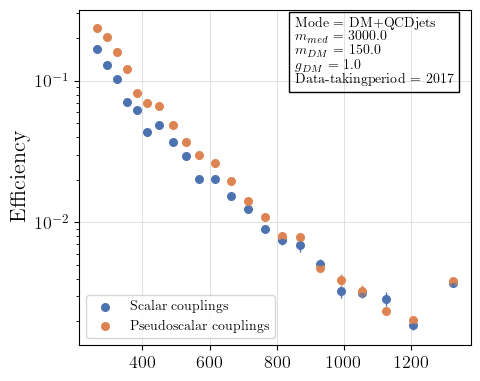

In [19]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots()

data = pd.DataFrame(columns=['Scalar','Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar','Pseudoscalar'])


colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax.scatter(x=binCenter, y=eff, s=30, color=colors[label], label=r'%s couplings' %(label))
    ax.errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

    
ax.set_yscale('log')
ax.text(.55, .78, textstr, fontsize=10, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax.set_ylabel('Efficiency')
ax.legend()
# plt.grid()
plt.tight_layout()
# plt.savefig('efficiencies_spin0_3000_150_onshell.png')

plt.show()

In [26]:
label = [c for c in recastData if (c.startswith("bin_") and not 'Error' in c)]

for l in label:
    ns = dfModel[l]
    nsErr = dfModel[f'{l}_ErrorPlus']
    lumi = dfModel['Luminosity (1/fb)']
    xsec = dfModel['Total xsec (pb)']
    dfModel[f'{l}_Efficiency'] = ns/(1e3*xsec*lumi)
    dfModel[f'{l}_Efficiency_Error'] = nsErr*(dfModel[f'{l}_Efficiency'])/ns
    dfModel[f'{l}_Efficiency_Error'] = dfModel[f'{l}_Efficiency_Error'].replace(np.nan, 0)

/tmp/ipykernel_127493/75460046.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfModel[f'{l}_Efficiency'] = ns/(1e3*xsec*lumi)
/tmp/ipykernel_127493/75460046.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfModel[f'{l}_Efficiency_Error'] = nsErr*(dfModel[f'{l}_Efficiency'])/ns
/tmp/ipykernel_127493/75460046.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [27]:
dfModel

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,bin_960.0_1020.0_Efficiency,bin_960.0_1020.0_Efficiency_Error,bin_1020.0_1090.0_Efficiency,bin_1020.0_1090.0_Efficiency_Error,bin_1090.0_1160.0_Efficiency,bin_1090.0_1160.0_Efficiency_Error,bin_1160.0_1250.0_Efficiency,bin_1160.0_1250.0_Efficiency_Error,bin_1250.0_1400.0_Efficiency,bin_1250.0_1400.0_Efficiency_Error
256,Scalar,DM+QCDjets,3000.0,150.0,2017,41.5,0.024307,0.001058,0.001058,0.018522,...,0.003252,0.000313,0.003178,0.000248,0.002884,0.000321,0.001876,0.000144,0.003730,0.000246
493,Pseudoscalar,DM+QCDjets,3000.0,150.0,2017,41.5,0.041615,0.002033,0.002033,0.036119,...,0.003917,0.000385,0.003265,0.000320,0.002372,0.000134,0.002024,0.000116,0.003838,0.000148


In [28]:
dataScalar = dfModel[dfModel['Coupling'] == 'Scalar']
dataPseudo = dfModel[dfModel['Coupling'] == 'Pseudoscalar']

In [29]:
# Setting the index with mass pairs
dataScalar = pd.DataFrame([dataScalar.set_index(['$m_{med}$', '$m_{DM}$'])[c] for c in dfModel if 'Efficiency' in c])
dataPseudo = pd.DataFrame([dataPseudo.set_index(['$m_{med}$', '$m_{DM}$'])[c] for c in dfModel if 'Efficiency' in c])

In [30]:
dataScalar

$m_{med}$,3000.0
$m_{DM}$,150.0
bin_250.0_280.0_Efficiency,0.168532
bin_250.0_280.0_Efficiency_Error,0.007333
bin_280.0_310.0_Efficiency,0.128428
bin_280.0_310.0_Efficiency_Error,0.006189
bin_310.0_340.0_Efficiency,0.103041
bin_310.0_340.0_Efficiency_Error,0.005202
bin_340.0_370.0_Efficiency,0.070917
bin_340.0_370.0_Efficiency_Error,0.003981
bin_370.0_400.0_Efficiency,0.061988


In [31]:
# Reduced chi squared statistics
maxDiff = []
chis = []
reducedChis = []
chisMax = []
for med, dm in dataScalar:
#     print(dm, med)
    # Relative difference
    reldiff = np.abs(dataScalar[med,dm].iloc[::2] - dataPseudo[med,dm].iloc[::2])/dataScalar[med,dm].iloc[::2]
    reldiff = reldiff.replace(np.inf, 0)
    reldiff = reldiff.max()
    # Chi-squared
    diff = (dataScalar[med,dm].iloc[::2] - dataPseudo[med,dm].iloc[::2])**2
    diff = diff.replace(np.inf, 0)
    errSysMult = 0.05 
    errPseudo = np.sqrt(np.array(dataPseudo[med,dm].iloc[1::2])**2 + (np.array(dataPseudo[med,dm].iloc[::2])*errSysMult)**2)
    errScalar = np.sqrt(np.array(dataScalar[med,dm].iloc[1::2])**2 + (np.array(dataScalar[med,dm].iloc[::2])*errSysMult)**2)
    sigmaTot = (errScalar + errPseudo)**2
#     errd = errd.replace(np.inf, 0)
    chi = []
    for i in range(len(diff)):
        if diff[i] == 0:
            chi.append(0)
        else:
            chi.append(diff[i]/sigmaTot[i])
    dof = len(diff) - 1
    chis.append(sum(chi))
    reducedChis.append(sum(chi)/dof)
    chisMax.append(max(chi))
    maxDiff.append(reldiff)

/tmp/ipykernel_127493/1962664025.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if diff[i] == 0:
/tmp/ipykernel_127493/1962664025.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  chi.append(diff[i]/sigmaTot[i])


In [32]:
reducedChis

[np.float64(3.59290328521296)]